<a href="https://colab.research.google.com/github/rads-fire/CNN_Lab/blob/main/24IT3040_RadhikaSharma_CNN_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

import tensorflow as tf
import numpy as np
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt

print("TensorFlow  :", tf.__version__)
print("NumPy       :", np.__version__)
print("Matplotlib  :", matplotlib.__version__)
print("Pandas      :", pd.__version__)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("\nGPU found:", gpus)
else:
    print("\nNo GPU found, running on CPU.")
#CPUs are slower because they don’t have as many parallel cores as GPUs. Tasks like matrix multiplication in CNNs can be done much faster on GPUs since they can handle many operations at once. If I were using a GPU, I’d enable mixed precision (float16) and use a larger batch size to make full use of its power
# pinning all the random seeds so results don't change between runs
import random
import os

random.seed(42)           # controls random module
np.random.seed(42)        # controls NumPy random operations like shuffles,initialisers,etc.
tf.random.set_seed(42)    # controls TensorFlow operations

print("\nAll seeds set to 42.")

TensorFlow  : 2.19.0
NumPy       : 2.0.2
Matplotlib  : 3.10.0
Pandas      : 2.2.2

GPU found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

All seeds set to 42.


In [13]:
from tensorflow.keras.datasets import mnist, cifar10

# loading both datasets
(x_train_m, y_train_m), (x_test_m, y_test_m) = mnist.load_data()
(x_train_c, y_train_c), (x_test_c, y_test_c) = cifar10.load_data()

# shapes
print("\nMNIST")
print("Train images:", x_train_m.shape, "  Train labels:", y_train_m.shape)
print("Test  images:", x_test_m.shape,  "  Test  labels:", y_test_m.shape)

print("\nCIFAR-10")
print("Train images:", x_train_c.shape, "  Train labels:", y_train_c.shape)
print("Test  images:", x_test_c.shape,  "  Test  labels:", y_test_c.shape)

# datatype and raw pixel range
print("\n dtype & value range")
print("MNIST   data type:", x_train_m.dtype,
      " min:", x_train_m.min(), " max: ", x_train_m.max())
print("CIFAR10 data type:", x_train_c.dtype,
      " min:", x_train_c.min(), " max: ", x_train_c.max())

# samples per class in MNIST training set
print("\n MNIST training samples per class")
for digit in range(10):
    count = np.sum(y_train_m == digit)
    print(f"  Class {digit}: {count} samples")

# roughly 6000 each, so yes it's balanced

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

MNIST
Train images: (60000, 28, 28)   Train labels: (60000,)
Test  images: (10000, 28, 28)   Test  labels: (10000,)

CIFAR-10
Train images: (50000, 32, 32, 3)   Train labels: (50000, 1)
Test  images: (10000, 32, 32, 3)   Test  labels: (10000, 1)

 dtype & value range
MNIST   data type: uint8  min: 0  max:  255
CIFAR10 data type: uint8  min: 0  max:  255

 MNIST training samples per class
  Class 0: 5923 samples
  Class 1: 6742 samples
  Class 2: 5958 samples
  Class 3: 6131 samples
  Class 4: 5842 samples
  Class 5: 5421 samples
  Class 6: 5918 samples
  Class 7: 6265 samples
  Class 8: 5851 samples
  Class 9: 5949 samples


/tmp/ipykernel_707/2347897470.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(cifar_names[int(y_train_c[cifar_idx[col]])], fontsize=20)


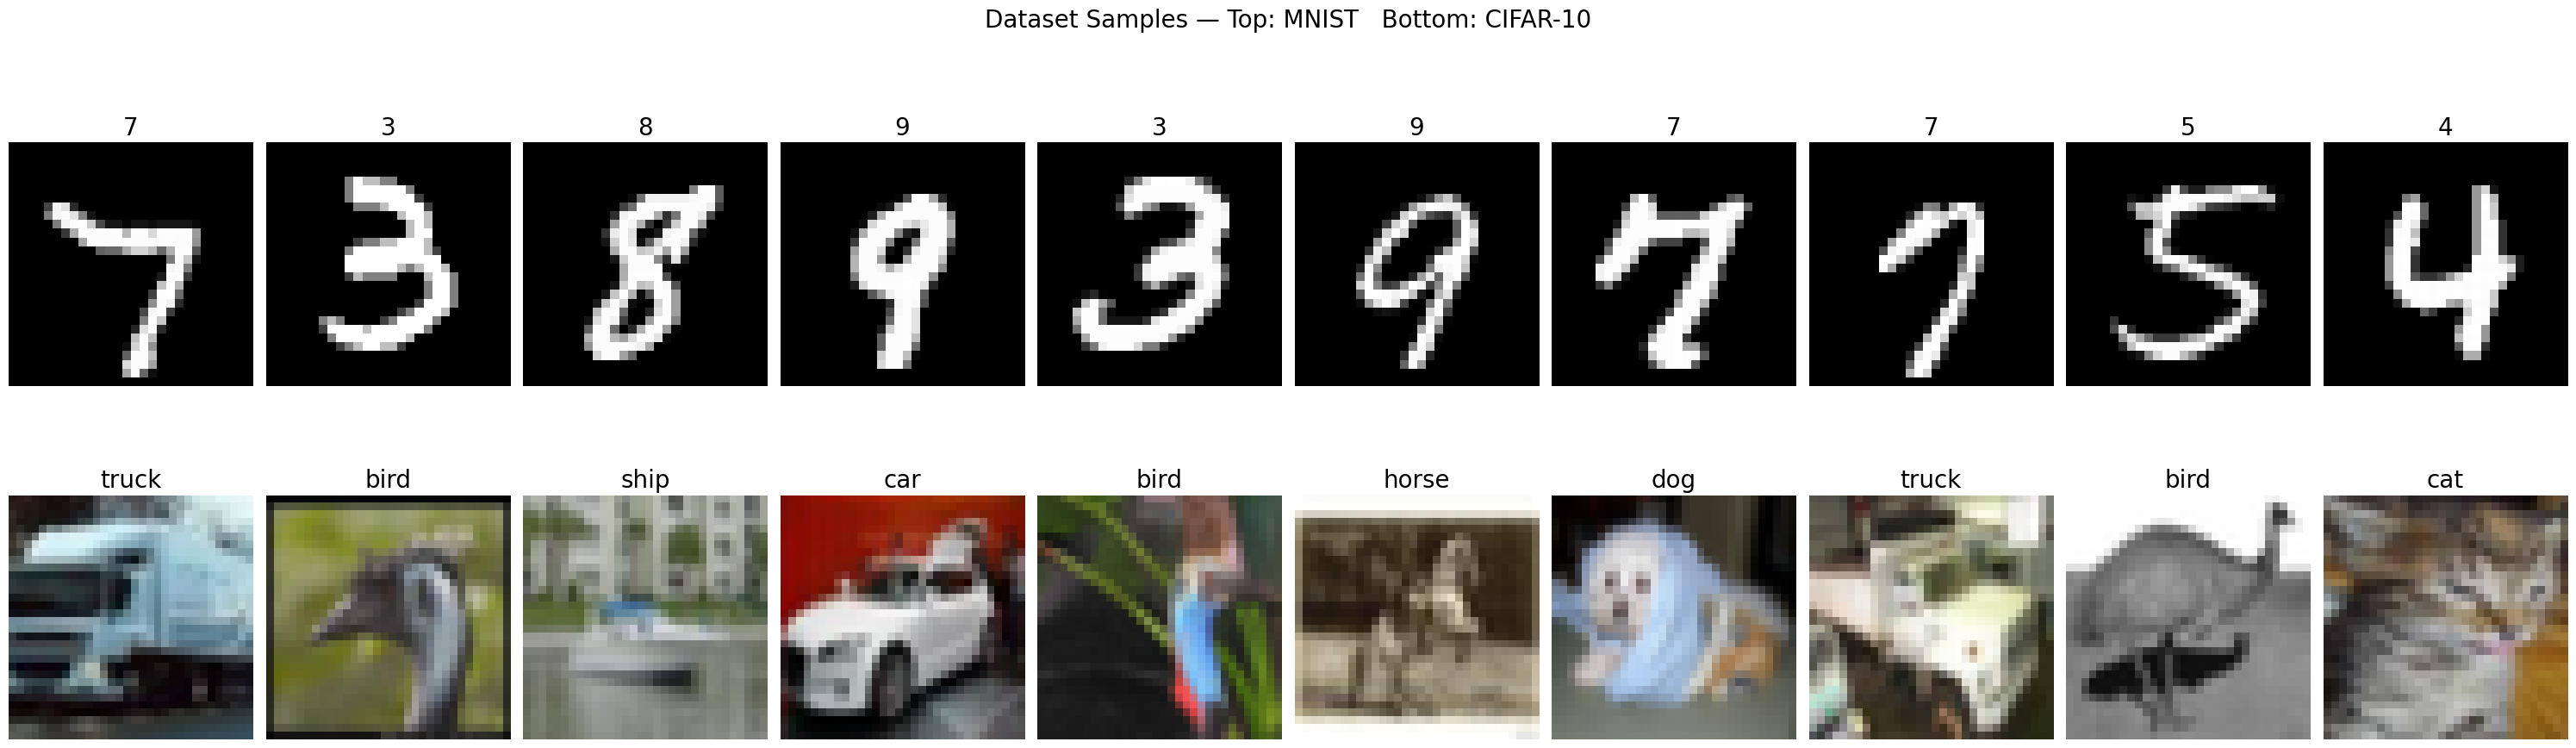

In [14]:
# plotting the 2x10 sample grid

cifar_names = [
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

np.random.seed(42)
mnist_idx  = np.random.choice(len(x_train_m), 10, replace=False)
cifar_idx  = np.random.choice(len(x_train_c), 10, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(30, 10))
fig.suptitle("Dataset Samples — Top: MNIST   Bottom: CIFAR-10", fontsize=20)

for col in range(10):
    # MNIST row
    ax = axes[0, col]
    ax.imshow(x_train_m[mnist_idx[col]], cmap='gray')
    ax.set_title(str(y_train_m[mnist_idx[col]]), fontsize=20)
    ax.axis('off')

    # CIFAR-10 row
    ax = axes[1, col]
    ax.imshow(x_train_c[cifar_idx[col]])
    ax.set_title(cifar_names[int(y_train_c[cifar_idx[col]])], fontsize=20)
    ax.axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()


In [15]:
def preprocess(images, labels, dataset='mnist'):

    print(f"\n MNIST preprocessing")
    print(f"Before , image shape: {images.shape}  datatype: {images.dtype}"
          f"  range: [{images.min()}, {images.max()}]")
    print(f"Before , label shape: {labels.shape}  sample: {labels[:5].flatten()}")

    # step 1: normalise to [0, 1] — must cast to float32 first
    # dividing by 255 (int) would return int; 255.0 gives float
    images = images.astype('float32') / 255.0

    print(f"\nAfter norm  | dtype: {images.dtype}"
          f"  range: [{images.min():.4f}, {images.max():.4f}]")

    # step 2: add channel dimension for MNIST (greyscale has no channel axis)
    if dataset == 'mnist':
        images = images[..., np.newaxis]   # (N,28,28) -> (N,28,28,1)
        print(f"After reshape | image shape: {images.shape}")

    # step 3: one-hot encode labels
    # manually doing what to_categorical does under the hood
    n_classes = 10
    n_samples = labels.shape[0]
    labels_flat = labels.flatten()                         # make sure it's 1D
    one_hot = np.zeros((n_samples, n_classes), dtype='float32')
    one_hot[np.arange(n_samples), labels_flat] = 1.0

    print(f"After one-hot | label shape: {one_hot.shape}"
          f"  sample row: {one_hot[0]}")

    return images, one_hot


# running it on both datasets
x_train_m_p, y_train_m_p = preprocess(x_train_m, y_train_m, 'mnist')
x_test_m_p,  y_test_m_p  = preprocess(x_test_m,  y_test_m,  'mnist')

x_train_c_p, y_train_c_p = preprocess(x_train_c, y_train_c, 'cifar10')
x_test_c_p,  y_test_c_p  = preprocess(x_test_c,  y_test_c,  'cifar10')


 MNIST preprocessing
Before , image shape: (60000, 28, 28)  datatype: uint8  range: [0, 255]
Before , label shape: (60000,)  sample: [5 0 4 1 9]

After norm  | dtype: float32  range: [0.0000, 1.0000]
After reshape | image shape: (60000, 28, 28, 1)
After one-hot | label shape: (60000, 10)  sample row: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

 MNIST preprocessing
Before , image shape: (10000, 28, 28)  datatype: uint8  range: [0, 255]
Before , label shape: (10000,)  sample: [7 2 1 0 4]

After norm  | dtype: float32  range: [0.0000, 1.0000]
After reshape | image shape: (10000, 28, 28, 1)
After one-hot | label shape: (10000, 10)  sample row: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]

 MNIST preprocessing
Before , image shape: (50000, 32, 32, 3)  datatype: uint8  range: [0, 255]
Before , label shape: (50000, 1)  sample: [6 9 9 4 1]

After norm  | dtype: float32  range: [0.0000, 1.0000]
After one-hot | label shape: (50000, 10)  sample row: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

 MNIST preprocessing
Before , image s

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_aug = ImageDataGenerator(
    horizontal_flip=True,      # 50% chance of flip
    rotation_range=10,         # random rotation
    zoom_range=0.10            # random zoom up to 10%
)

# no augmentation for test
test_gen = ImageDataGenerator()

# Augmentation only for training — validation/test must stay untouched because augmentation changes the image content; if we apply it to the test set we're evaluating on a different distribution than real-world data, which makes accuracy numbers meaningless.

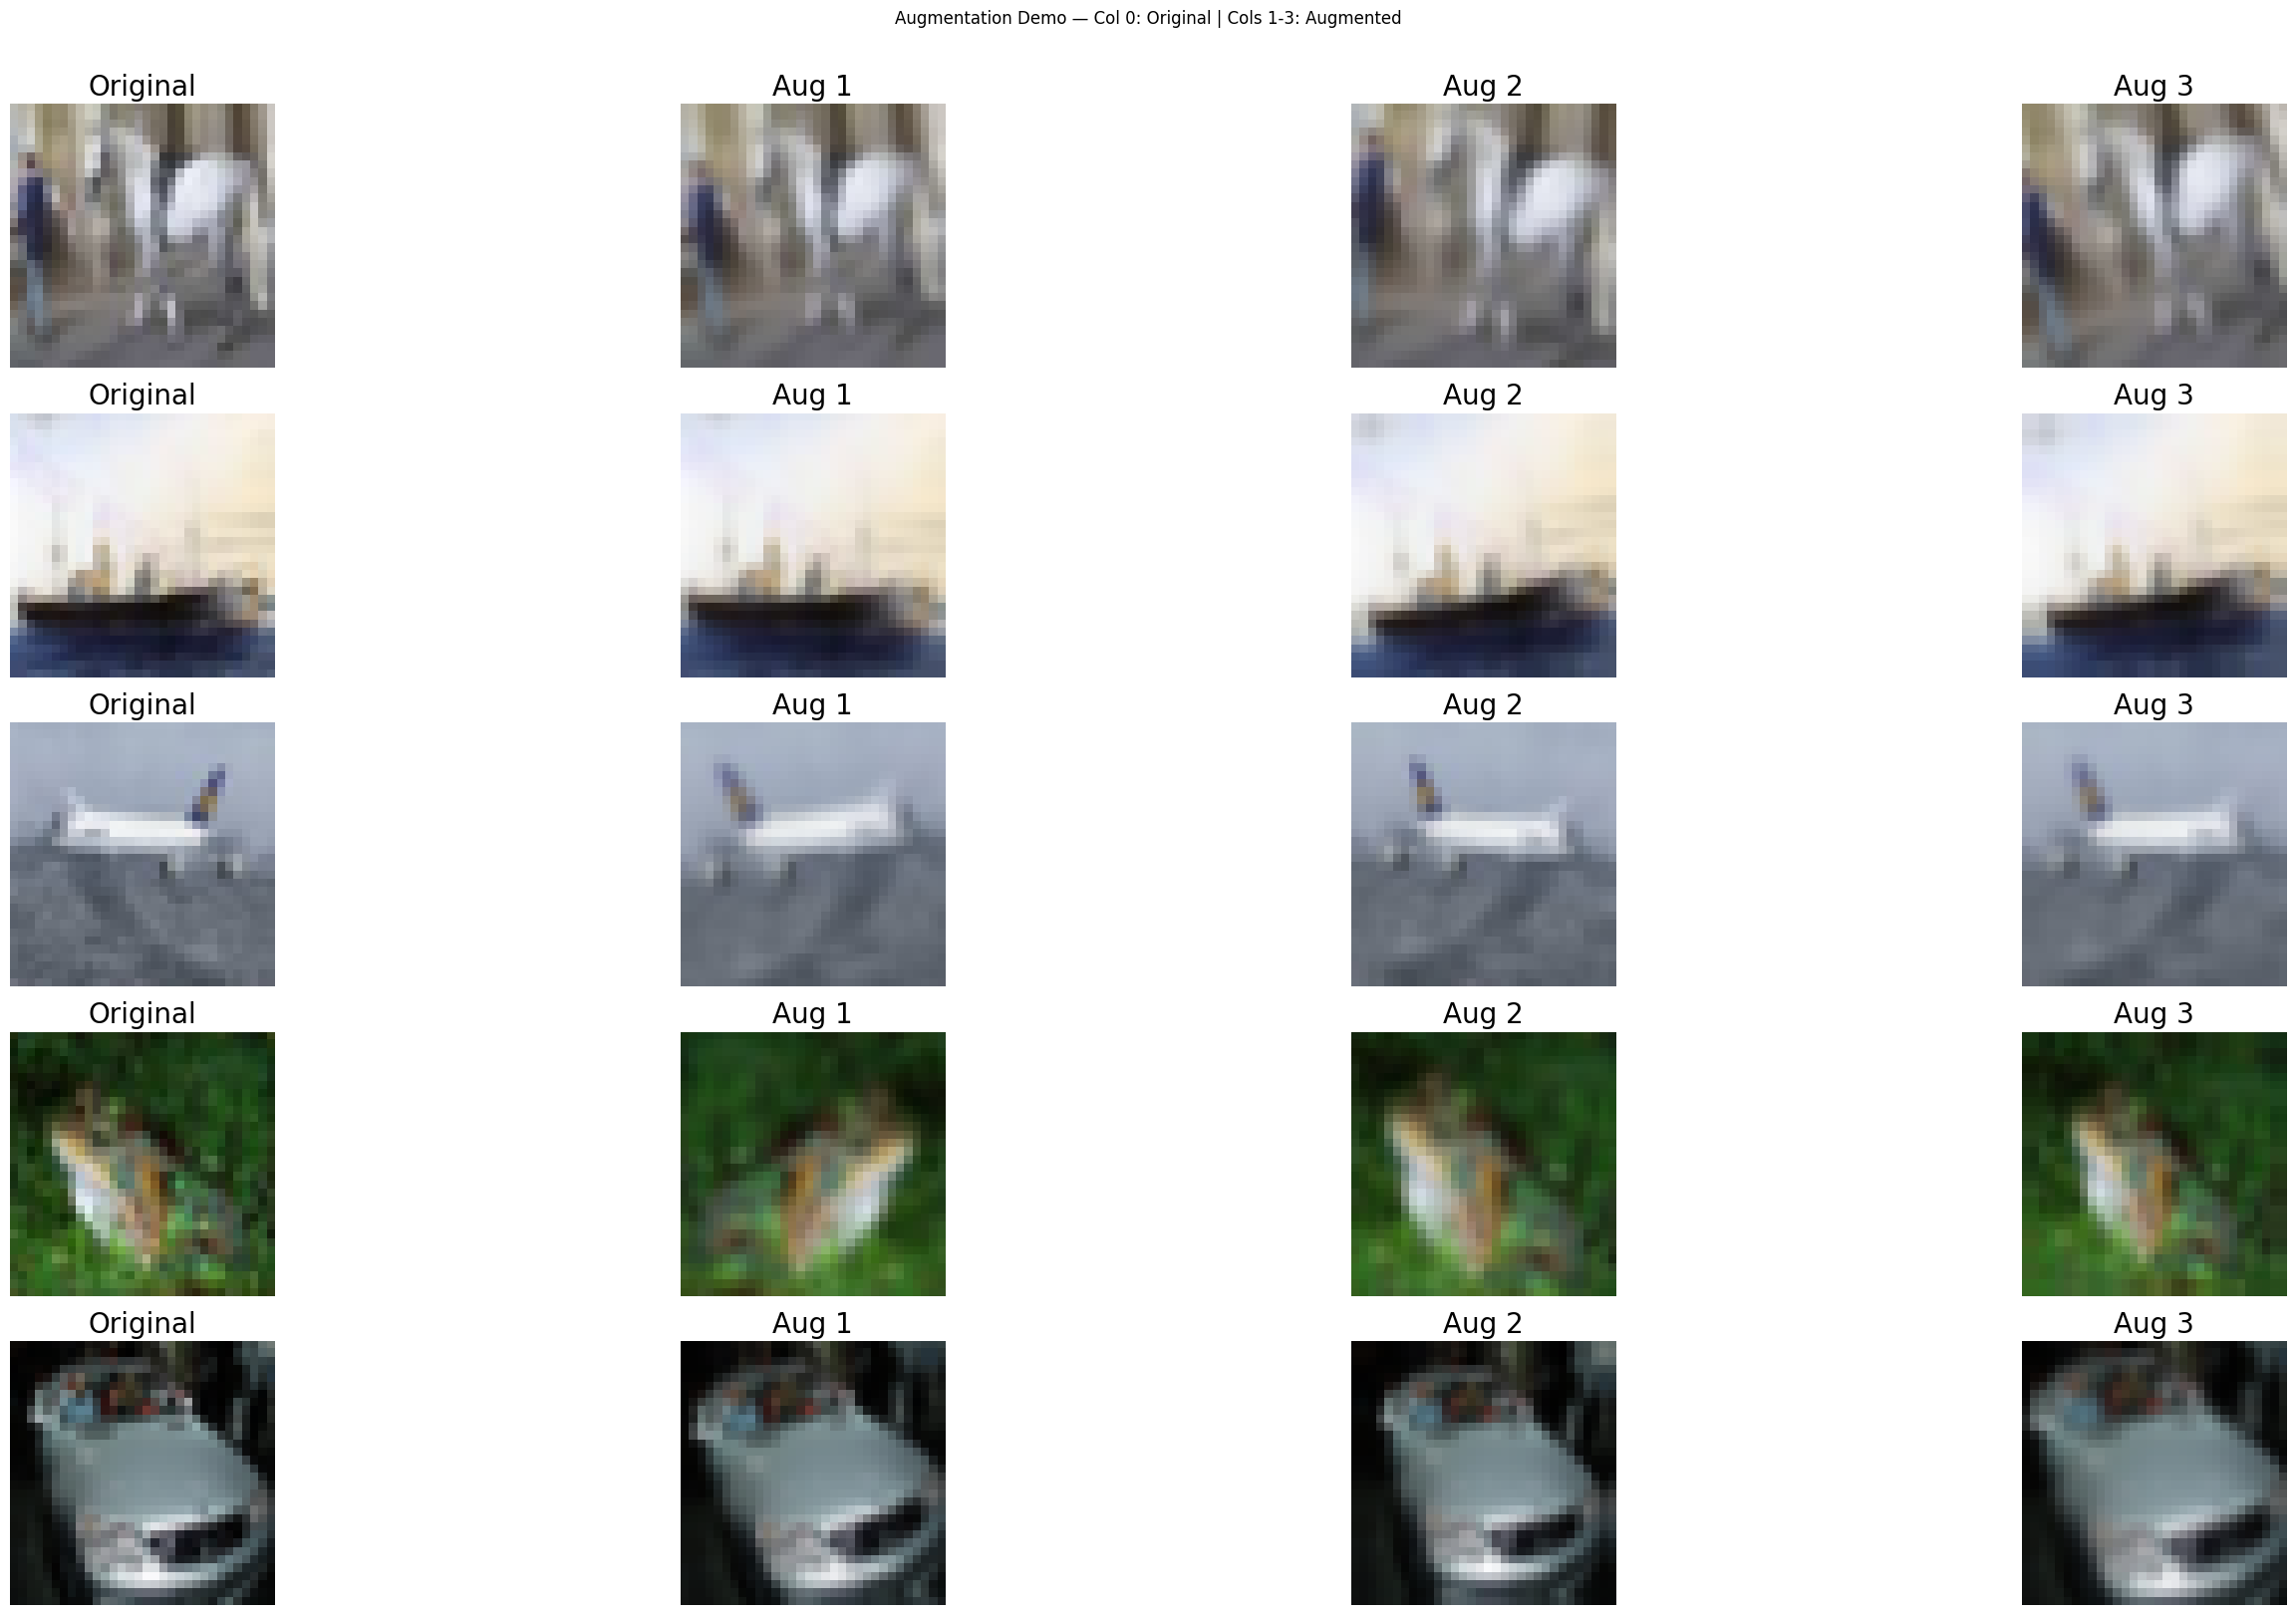

Saved: augmentation_demo.png


In [17]:

def augment_image(img):
    # img should be float32 in [0,1], shape (32,32,3)
    img = tf.image.random_flip_left_right(img)
    img = tf.keras.layers.RandomRotation(factor=10/360)(
              img[np.newaxis, ...], training=True)[0]
    img = tf.keras.layers.RandomZoom(height_factor=0.1)(
              img[np.newaxis, ...], training=True)[0]
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img.numpy()

np.random.seed(42)
tf.random.set_seed(42)

sample_idx = np.random.choice(len(x_train_c_p), 5, replace=False)
samples    = x_train_c_p[sample_idx]   # (5, 32, 32, 3)

fig, axes = plt.subplots(5, 4, figsize=(30, 16))
fig.suptitle("Augmentation Demo — Col 0: Original | Cols 1-3: Augmented",
             fontsize=12, y=1.01)

for row in range(5):
    img = samples[row]

    # col 0 — original
    axes[row, 0].imshow(img)
    axes[row, 0].set_title("Original", fontsize=20)
    axes[row, 0].axis('off')

    # cols 1-3 — three different augmented versions of the same image
    for col in range(1, 4):
        aug_img = augment_image(img)
        axes[row, col].imshow(aug_img)
        axes[row, col].set_title(f"Aug {col}", fontsize=20)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig("augmentation_demo.png")
plt.show()
print("Saved: augmentation_demo.png")


# Q1 — What does the channel dimension C represent in (N, H, W, C)?

# N = batch size (number of images), H = height in pixels, W = width.
# C is the number of channels — basically how many values describe each pixel.
# For a greyscale image C=1 (just brightness). For an RGB image C=3
# (separate red, green, blue intensity values). Some satellite images have
# C=4 (adding an infrared band). The CNN's first conv layer learns a filter
# for each input channel and combines them.

-------------------------------------------



# Q2 — Loading 1024×1024 images without running out of memory

# Two practical strategies:
#
# 1. Use a data generator / tf.data pipeline that loads images from disk
#    in small batches on-the-fly instead of holding the full dataset in RAM.
#    Only one batch lives in memory at a time, so RAM usage is bounded by
#    batch_size × image_size rather than dataset_size × image_size.
#
# 2. Random cropping / patch-based training: instead of feeding the full
#    1024×1024 image, randomly crop a fixed-size patch (e.g., 256×256)
#    per iteration. This also acts as free augmentation and lets you train
#    on very large images with modest hardware.

-------------------------------------------
# Q3 — Wrong to normalise test set with test set's own mean/std?

# The model was trained assuming the normalisation statistics come from
# the training data. At deployment you will never have the test set's
# statistics in advance — you only have the training stats.
# Using test-set stats during evaluation also leaks information about the
# test set into the preprocessing step, which inflates reported accuracy.
# The correct approach is to compute mean and std on the training set only
# and apply those same values to both the validation and test sets.

-------------------------------------------

Output feature map:
[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]

Output shape: (3, 3)

Expected shape from formula: 3 x 3  — matches: True


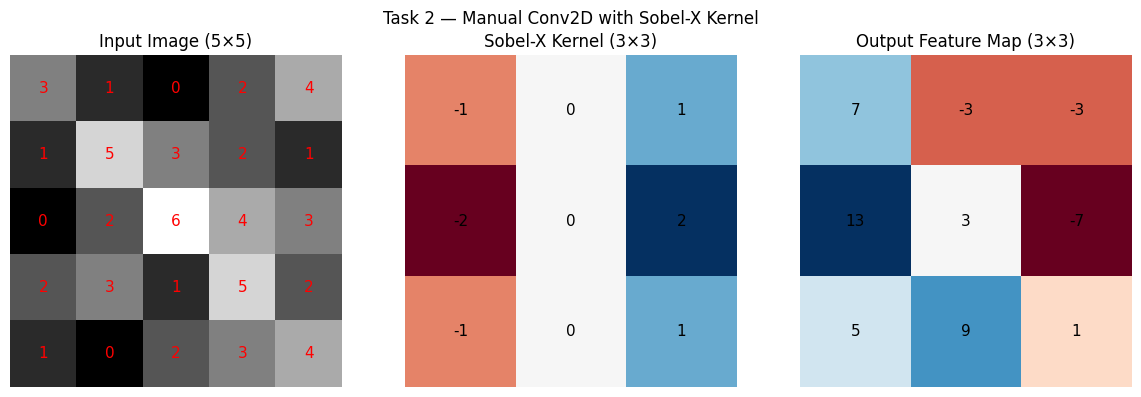

Saved: conv2d_manual.png


In [18]:
# ============================================================
# Task 2 - Problem 1: Manual 2D Convolution (NumPy only)
# ============================================================

# writing convolution from scratch using only numpy
# no scipy, no tf, no torch — just loops and arithmetic

def conv2d(image, kernel, stride=1, padding=0):

    # pad the image with zeros on all sides if needed
    if padding > 0:
        image = np.pad(image, padding, mode='constant', constant_values=0)

    img_h, img_w = image.shape
    ker_h, ker_w = kernel.shape

    # output size formula from the primer:
    # Output = floor((Input - Kernel + 2*Padding) / Stride) + 1
    # padding is already baked into img_h/img_w at this point so no 2*P term
    out_h = int((img_h - ker_h) / stride) + 1
    out_w = int((img_w - ker_w) / stride) + 1

    output = np.zeros((out_h, out_w))

    # slide the kernel window across every position
    for i in range(out_h):
        for j in range(out_w):
            patch = image[i*stride : i*stride+ker_h,
                          j*stride : j*stride+ker_w]
            # dot product between patch and kernel — that's all convolution is
            output[i, j] = np.sum(patch * kernel)

    return output


# ---- test case from the assignment ----

test_image = np.array([
    [3, 1, 0, 2, 4],
    [1, 5, 3, 2, 1],
    [0, 2, 6, 4, 3],
    [2, 3, 1, 5, 2],
    [1, 0, 2, 3, 4]
], dtype=np.float32)

# sobel-x picks up vertical edges (intensity changes left-right)
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

result = conv2d(test_image, sobel_x, stride=1, padding=0)

print("Output feature map:")
print(result)
print("\nOutput shape:", result.shape)

# manually verifying shape with the formula before running
expected = int((5 - 3 + 2*0) / 1) + 1
print(f"\nExpected shape from formula: {expected} x {expected}  — matches: {result.shape == (expected, expected)}")


# ---- visualise it so the numbers make more sense ----

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Task 2 — Manual Conv2D with Sobel-X Kernel", fontsize=12)

axes[0].imshow(test_image, cmap='gray')
axes[0].set_title("Input Image (5×5)")
axes[0].axis('off')
# label each pixel value so we can cross-check by hand
for i in range(5):
    for j in range(5):
        axes[0].text(j, i, int(test_image[i, j]),
                     ha='center', va='center', fontsize=11, color='red')

axes[1].imshow(sobel_x, cmap='RdBu')
axes[1].set_title("Sobel-X Kernel (3×3)")
axes[1].axis('off')
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, int(sobel_x[i, j]),
                     ha='center', va='center', fontsize=11, color='black')

axes[2].imshow(result, cmap='RdBu')
axes[2].set_title("Output Feature Map (3×3)")
axes[2].axis('off')
for i in range(3):
    for j in range(3):
        axes[2].text(j, i, int(result[i, j]),
                     ha='center', va='center', fontsize=11, color='black')

plt.tight_layout()
plt.savefig("conv2d_manual.png", dpi=150)
plt.show()
print("Saved: conv2d_manual.png")

In [19]:
# ============================================================
# Task 2 - Problem 3: LeNet-5 Implementation
# ============================================================

# building LeNet-5 exactly as described in the 1998 paper
# no batch norm, no relu, no dropout — keeping it original

def build_lenet5():
    model = tf.keras.Sequential([

        # block 1: first conv + avg pool
        # 28x28x1 -> 24x24x6 -> 12x12x6
        tf.keras.layers.Conv2D(6, kernel_size=5, padding='valid',
                               activation='tanh', input_shape=(28, 28, 1)),
        tf.keras.layers.AveragePooling2D(pool_size=2, strides=2),

        # block 2: second conv + avg pool
        # 12x12x6 -> 8x8x16 -> 4x4x16
        tf.keras.layers.Conv2D(16, kernel_size=5, padding='valid',
                               activation='tanh'),
        tf.keras.layers.AveragePooling2D(pool_size=2, strides=2),

        # flatten 4x4x16 = 256 units going into dense layers
        tf.keras.layers.Flatten(),

        # fully connected head
        tf.keras.layers.Dense(120, activation='tanh'),
        tf.keras.layers.Dense(84,  activation='tanh'),
        tf.keras.layers.Dense(10,  activation='softmax')   # 10 MNIST classes

    ], name='LeNet5')

    return model


lenet = build_lenet5()
lenet.summary()


# ---- manual parameter count for each layer ----
# formula: (K * K * C_in + 1) * C_out   (+1 is the bias per filter)

print("\n--- Manual parameter verification ---")

# layer 1: Conv2D — K=5, C_in=1 (greyscale), C_out=6
l1 = (5 * 5 * 1 + 1) * 6
print(f"Conv2D-1  : (5×5×1 + 1) × 6  = {l1}")

# layer 2: Conv2D — K=5, C_in=6 (from prev layer), C_out=16
l2 = (5 * 5 * 6 + 1) * 16
print(f"Conv2D-2  : (5×5×6 + 1) × 16 = {l2}")

# layer 3: Dense — input=4*4*16=256, output=120
# formula for dense: (input_units + 1) * output_units
l3 = (256 + 1) * 120
print(f"Dense-120 : (256 + 1) × 120  = {l3}")

# layer 4: Dense — 120 -> 84
l4 = (120 + 1) * 84
print(f"Dense-84  : (120 + 1) × 84   = {l4}")

# layer 5: Dense — 84 -> 10
l5 = (84 + 1) * 10
print(f"Dense-10  : (84  + 1) × 10   = {l5}")

total = l1 + l2 + l3 + l4 + l5
print(f"\nTotal (manual) : {total}")
print(f"Total (summary): {lenet.count_params()}")
print(f"Match          : {total == lenet.count_params()}  — expected 44,426")


# ---- answering why AvgPool in LeNet but MaxPool everywhere today ----
print("""
Why AvgPool in LeNet-5 but MaxPool now?
----------------------------------------
LeNet was designed in 1998 when the idea was to take a smooth spatial
average — sort of a gentle downsampling that keeps gradient flow clean.
MaxPool came to dominate later (AlexNet 2012 onwards) because it keeps
only the strongest activation in each region, which gives sharper feature
detection and proved empirically better on harder datasets like ImageNet.
AvgPool is still used occasionally — notably in the GlobalAveragePooling
layer at the end of modern nets — but max pooling wins in intermediate layers.
""")

Model: "LeNet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_10            │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_11            │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)


--- Manual parameter verification ---
Conv2D-1  : (5×5×1 + 1) × 6  = 156
Conv2D-2  : (5×5×6 + 1) × 16 = 2416
Dense-120 : (256 + 1) × 120  = 30840
Dense-84  : (120 + 1) × 84   = 10164
Dense-10  : (84  + 1) × 10   = 850

Total (manual) : 44426
Total (summary): 44426
Match          : True  — expected 44,426

Why AvgPool in LeNet-5 but MaxPool now?
----------------------------------------
LeNet was designed in 1998 when the idea was to take a smooth spatial
average — sort of a gentle downsampling that keeps gradient flow clean.
MaxPool came to dominate later (AlexNet 2012 onwards) because it keeps
only the strongest activation in each region, which gives sharper feature
detection and proved empirically better on harder datasets like ImageNet.
AvgPool is still used occasionally — notably in the GlobalAveragePooling
layer at the end of modern nets — but max pooling wins in intermediate layers.



Model: "LeNet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_40 (Activation)      │ (None, 24, 24, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_12            │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_41 (Activation)      │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_13            │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_42 (Activation)      │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_43 (Activation)      │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7614 - loss: 0.9254 - val_accuracy: 0.9047 - val_loss: 0.3915
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8946 - loss: 0.3877 - val_accuracy: 0.9300 - val_loss: 0.2734
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9140 - loss: 0.3037 - val_accuracy: 0.9418 - val_loss: 0.2219
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9272 - loss: 0.2527 - val_accuracy: 0.9515 - val_loss: 0.1853
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9385 - loss: 0.2121 - val_accuracy: 0.9622 - val_loss: 0.1562
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9480 - loss: 0.1796 - val_accuracy: 0.9663 - val_loss: 0.1341
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9551 - loss: 0.1550 - val_accuracy: 0.9698 - val_loss: 0.1184
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9607 - loss: 0.1370 - val_accuracy: 0.

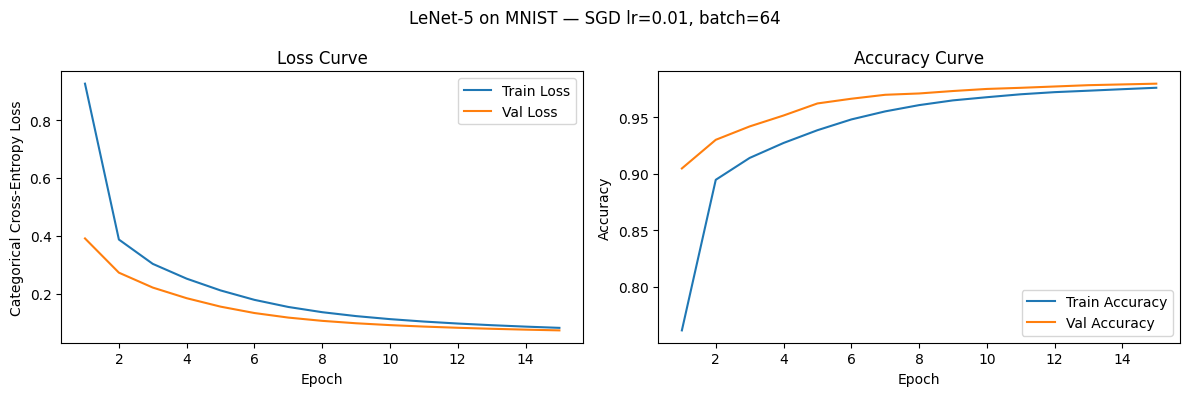

Saved: lenet_sgd_curves.png

Final Test Loss    : 0.0730
Final Test Accuracy: 0.9770  (97.70%)


In [20]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Activation

np.random.seed(42)
tf.random.set_seed(42)

# -------- load & preprocess --------
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

# np.eye is cleaner than a for-loop for one-hot encoding
y_train_oh = np.eye(10)[y_train]
y_test_oh  = np.eye(10)[y_test]


# -------- build LeNet-5 --------
# keeping activation as a separate layer to match the original 1998 paper style
lenet_model = Sequential([
    Conv2D(6, (5,5), padding='valid', input_shape=(28,28,1)),
    Activation('tanh'),
    AveragePooling2D(pool_size=(2,2), strides=2),

    Conv2D(16, (5,5), padding='valid'),
    Activation('tanh'),
    AveragePooling2D(pool_size=(2,2), strides=2),

    Flatten(),

    Dense(120), Activation('tanh'),
    Dense(84),  Activation('tanh'),
    Dense(10,   activation='softmax')
], name='LeNet5')

lenet_model.summary()


# -------- compile --------
lenet_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# -------- train --------
history = lenet_model.fit(
    x_train, y_train_oh,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)


# -------- find overfitting epoch --------
# overfitting = val_loss starts going up while train_loss keeps dropping
val_loss = history.history['val_loss']
overfit_epoch = None

for ep in range(1, len(val_loss)):
    if val_loss[ep] > val_loss[ep - 1]:
        overfit_epoch = ep + 1   # +1 because epochs are 1-indexed
        break

if overfit_epoch:
    print(f"\nOverfitting first appears at epoch {overfit_epoch}")
    print(f"val_loss went from {val_loss[overfit_epoch-2]:.4f} → {val_loss[overfit_epoch-1]:.4f}")
else:
    print("\nNo clear overfitting detected across 15 epochs")


# -------- plot --------
epochs_range = range(1, 16)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("LeNet-5 on MNIST — SGD lr=0.01, batch=64", fontsize=12)

# loss curve
axes[0].plot(epochs_range, history.history['loss'],     label='Train Loss')
axes[0].plot(epochs_range, history.history['val_loss'], label='Val Loss')
if overfit_epoch:
    axes[0].axvline(x=overfit_epoch, color='red', linestyle='--', alpha=0.7,
                    label=f'Overfit starts (ep {overfit_epoch})')
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Categorical Cross-Entropy Loss")
axes[0].legend()

# accuracy curve
axes[1].plot(epochs_range, history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy')
if overfit_epoch:
    axes[1].axvline(x=overfit_epoch, color='red', linestyle='--', alpha=0.7,
                    label=f'Overfit starts (ep {overfit_epoch})')
axes[1].set_title("Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("lenet_sgd_curves.png", dpi=150)
plt.show()
print("Saved: lenet_sgd_curves.png")


# -------- final test accuracy --------
test_loss, test_acc = lenet_model.evaluate(x_test, y_test_oh, verbose=0)
print(f"\nFinal Test Loss    : {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")

In [21]:
def create_lenet():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Activation

    model = Sequential(name='LeNet5')

    # block 1 — 28x28x1 → 24x24x6 → 12x12x6
    model.add(Conv2D(6, (5,5), padding='valid', input_shape=(28,28,1)))
    model.add(Activation('tanh'))
    model.add(AveragePooling2D(pool_size=(2,2), strides=2))

    # block 2 — 12x12x6 → 8x8x16 → 4x4x16
    model.add(Conv2D(16, (5,5), padding='valid'))
    model.add(Activation('tanh'))
    model.add(AveragePooling2D(pool_size=(2,2), strides=2))

    # flatten 4x4x16 = 256 → dense head
    model.add(Flatten())

    model.add(Dense(120))
    model.add(Activation('tanh'))

    model.add(Dense(84))
    model.add(Activation('tanh'))

    # 10 output units — one per MNIST digit class
    model.add(Dense(10, activation='softmax'))

    return model

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7765 - loss: 0.8794 - val_accuracy: 0.9067 - val_loss: 0.3676
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8947 - loss: 0.3788 - val_accuracy: 0.9265 - val_loss: 0.2670
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9134 - loss: 0.3018 - val_accuracy: 0.9392 - val_loss: 0.2185
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9274 - loss: 0.2534 - val_accuracy: 0.9505 - val_loss: 0.1848
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9375 - loss: 0.2168 - val_accuracy: 0.9580 - val_loss: 0.1594
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9458 - loss: 0.1878 - val_accuracy: 0.9637 - val_loss: 0.1399
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9524 - loss: 0.1650 - val_accuracy: 0.9678 - val_loss: 0.1251
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9575 - loss: 0.1470 - val_accuracy: 0.

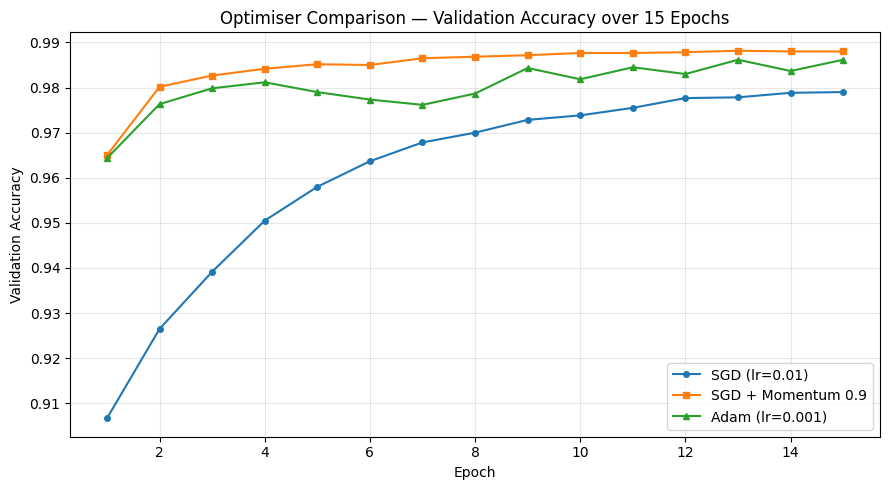

Saved: optimiser_comparison.png

--- Final Val Accuracy (Epoch 15) ---
SGD plain     : 0.9790
SGD + Momentum: 0.9880
Adam          : 0.9862
SGD+Mom first hit 98% at epoch 2
Adam first hit 98% at epoch 4


In [22]:
from tensorflow.keras.optimizers import SGD, Adam

epochs_range = range(1, 16)

# -------- SGD (no momentum) --------
tf.random.set_seed(42)
np.random.seed(42)

model_sgd = create_lenet()
model_sgd.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
hist_sgd = model_sgd.fit(
    x_train, y_train_oh,
    epochs=15, batch_size=64,
    validation_split=0.1,
    verbose=1
)


# -------- SGD + Momentum --------
# momentum helps SGD accumulate velocity in the right direction
# so it converges faster than plain SGD
tf.random.set_seed(42)
np.random.seed(42)

model_mom = create_lenet()
model_mom.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
hist_mom = model_mom.fit(
    x_train, y_train_oh,
    epochs=15, batch_size=64,
    validation_split=0.1,
    verbose=1
)


# -------- Adam --------
# adam adapts the learning rate per parameter so it usually
# converges fastest — but uses a lower lr (0.001) by convention
tf.random.set_seed(42)
np.random.seed(42)

model_adam = create_lenet()
model_adam.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
hist_adam = model_adam.fit(
    x_train, y_train_oh,
    epochs=15, batch_size=64,
    validation_split=0.1,
    verbose=1
)


# -------- plot all three val accuracy curves on one figure --------
plt.figure(figsize=(9, 5))

plt.plot(epochs_range, hist_sgd.history['val_accuracy'],
         label='SGD (lr=0.01)', marker='o', markersize=4)
plt.plot(epochs_range, hist_mom.history['val_accuracy'],
         label='SGD + Momentum 0.9', marker='s', markersize=4)
plt.plot(epochs_range, hist_adam.history['val_accuracy'],
         label='Adam (lr=0.001)', marker='^', markersize=4)

plt.title("Optimiser Comparison — Validation Accuracy over 15 Epochs")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("optimiser_comparison.png", dpi=150)
plt.show()
print("Saved: optimiser_comparison.png")


# -------- print final numbers so observations are easy to write --------
print("\n--- Final Val Accuracy (Epoch 15) ---")
print(f"SGD plain     : {hist_sgd.history['val_accuracy'][-1]:.4f}")
print(f"SGD + Momentum: {hist_mom.history['val_accuracy'][-1]:.4f}")
print(f"Adam          : {hist_adam.history['val_accuracy'][-1]:.4f}")

# which one crossed 0.98 first (if any)
for name, hist in [('SGD', hist_sgd), ('SGD+Mom', hist_mom), ('Adam', hist_adam)]:
    for ep, acc in enumerate(hist.history['val_accuracy'], 1):
        if acc >= 0.98:
            print(f"{name} first hit 98% at epoch {ep}")
            break

In [23]:
def create_model():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
    from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
    from tensorflow.keras.layers import Dense, Dropout

    model = Sequential(name='CustomCIFAR10_CNN')

    # block 1 — 32x32x3 → 32x32x64 → 16x16x64
    # 'same' padding keeps spatial size before pooling halves it
    model.add(Conv2D(64, (3,3), padding='same', input_shape=(32,32,3)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))

    # block 2 — 16x16x64 → 16x16x128 → 8x8x128
    model.add(Conv2D(128, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))

    # block 3 — 8x8x128 → 8x8x256 → 4x4x256
    model.add(Conv2D(256, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))

    # GAP squashes 4x4x256 → 256 — no spatial info but way fewer params
    # than Flatten() which would give 4*4*256 = 4096 inputs to Dense
    model.add(GlobalAveragePooling2D())

    # classification head
    model.add(Dense(128))
    model.add(Activation('relu'))
    model.add(Dropout(0.5))   # kills 50% of neurons during training to reduce overfit

    # 10 CIFAR-10 classes
    model.add(Dense(10, activation='softmax'))

    return model


# build and check param count is within 200K - 2M
custom_model = create_model()
custom_model.summary()

total_params = custom_model.count_params()
print(f"\nTotal parameters : {total_params:,}")
print(f"Within 200K-2M   : {200_000 <= total_params <= 2_000_000}")


# ---- design rationale ----
print("""
Design Rationale
-----------------
Three conv blocks with filter counts doubling each time (64 → 128 → 256)
so early layers learn simple edges and later layers build up to object parts.
BatchNorm after every conv stabilises training and lets us use a higher lr
without the gradients blowing up. GlobalAveragePooling instead of Flatten
keeps the parameter count low — a Flatten here would dump 4096 units into
the Dense head and balloon the total count well past 2M. A single Dropout(0.5)
before the output layer handles regularisation in the head.
""")

Model: "CustomCIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_35 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_56 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_57 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_58 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_59 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,794 (1.55 MB)

 Trainable params: 405,898 (1.55 MB)

 Non-trainable params: 896 (3.50 KB)


Total parameters : 406,794
Within 200K-2M   : True

Design Rationale
-----------------
Three conv blocks with filter counts doubling each time (64 → 128 → 256)
so early layers learn simple edges and later layers build up to object parts.
BatchNorm after every conv stabilises training and lets us use a higher lr
without the gradients blowing up. GlobalAveragePooling instead of Flatten
keeps the parameter count low — a Flatten here would dump 4096 units into
the Dense head and balloon the total count well past 2M. A single Dropout(0.5)
before the output layer handles regularisation in the head.



In [24]:
import pandas as pd

results = {}

learning_rates = [0.1, 0.01, 0.001]
batch_sizes    = [32, 128]

for lr in learning_rates:
    for bs in batch_sizes:

        # reset seeds before every run so weight initialisation
        # is identical across all 6 combinations — fair comparison
        tf.random.set_seed(42)
        np.random.seed(42)

        print(f"\nTraining  LR={lr}  batch={bs} ...")

        model = create_model()
        model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            x_train_c_p, y_train_c_p,
            epochs=10,
            batch_size=bs,
            validation_split=0.1,
            verbose=0          # keeping output clean — just printing final acc
        )

        final_val_acc = history.history['val_accuracy'][-1]
        results[(lr, bs)] = round(final_val_acc, 4)
        print(f"  → val accuracy: {final_val_acc:.4f}")


# ---- present as a 3x2 table (rows=LR, cols=batch size) ----
print("\n--- Grid Search Results (Val Accuracy after 10 epochs) ---\n")

table = pd.DataFrame(
    index=[f"lr={lr}" for lr in learning_rates],
    columns=[f"batch={bs}" for bs in batch_sizes]
)

for lr in learning_rates:
    for bs in batch_sizes:
        table.loc[f"lr={lr}", f"batch={bs}"] = results[(lr, bs)]

print(table.to_string())


# ---- find best and worst combination ----
best_combo = max(results, key=results.get)
worst_combo = min(results, key=results.get)

print(f"\nBest  combination : LR={best_combo[0]}, batch={best_combo[1]}"
      f"  → val acc = {results[best_combo]:.4f}")
print(f"Worst combination : LR={worst_combo[0]}, batch={worst_combo[1]}"
      f"  → val acc = {results[worst_combo]:.4f}")

print("""
Observation
------------
High LR (0.1) tends to overshoot minima so val accuracy is usually lower,
especially with small batches where gradient estimates are noisy.
Lower LR (0.001) with small batches is more stable but may not converge
fully in just 10 epochs. The middle ground (lr=0.01, batch=32 or 128)
typically hits the best balance for a shallow training run like this.
""")


Training  LR=0.1  batch=32 ...
  → val accuracy: 0.7076

Training  LR=0.1  batch=128 ...
  → val accuracy: 0.4514

Training  LR=0.01  batch=32 ...
  → val accuracy: 0.4926

Training  LR=0.01  batch=128 ...
  → val accuracy: 0.5980

Training  LR=0.001  batch=32 ...
  → val accuracy: 0.4404

Training  LR=0.001  batch=128 ...
  → val accuracy: 0.4870

--- Grid Search Results (Val Accuracy after 10 epochs) ---

         batch=32 batch=128
lr=0.1     0.7076    0.4514
lr=0.01    0.4926     0.598
lr=0.001   0.4404     0.487

Best  combination : LR=0.1, batch=32  → val acc = 0.7076
Worst combination : LR=0.001, batch=32  → val acc = 0.4404

Observation
------------
High LR (0.1) tends to overshoot minima so val accuracy is usually lower,
especially with small batches where gradient estimates are noisy.
Lower LR (0.001) with small batches is more stable but may not converge
fully in just 10 epochs. The middle ground (lr=0.01, batch=32 or 128)
typically hits the best balance for a shallow train